## Compare optimized implementation of blur measurement with older version

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
# Add project root to path so `src` is importable when running from notebooks/
from pathlib import Path
import sys


project_root = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [5]:
## Setup and Imports

import os
import logging
from typing import Dict, List, Optional, Union

# Import visualization libraries
# # Use interactive backend for matplotlib
import matplotlib
# matplotlib.use('ipympl')
import matplotlib.pyplot as plt

# import numpy as np
# from tqdm.notebook import tqdm

# from matplotlib.widgets import Slider

import tifffile as tiff
import numpy as np
import time
from pathlib import Path


# Import preprocessing modules
# from src.utils.file_utils import BlurFileHandler
# from src.utils.visualization_utils import plot_blur_heatmap, plot_blur_heatmap_3D

from src.utils.blur_measure import measure_patchwise_blur, measure_patchwise_blur_fast




## Compare naive vs fast implementation

### Quantitative comparison

In [6]:
# Test data directory
test_dir = Path('../data/Plate 2426_preprocessed_2D/test')

# Get a few test images
test_images = list(test_dir.glob('*.tif'))[:3]  # Use first 3 images for testing
n_images = len(test_images)


In [ ]:

# Test parameters
test_params = [
    {'patch_size': 16, 'stride_size': 1, 'center_values': True},
    {'patch_size': 32, 'stride_size': 1, 'center_values': True},
    {'patch_size': 64, 'stride_size': 1, 'center_values': True},
    {'patch_size': 32, 'stride_size': 1, 'center_values': True},
]

print("Testing blur measurement methods comparison")
print("=" * 60)

results = []
results_img = {}

store_images = True  # Set to True to store blur maps and timings in results_img

for img_path in test_images:
    print(f"\n📸 Testing image: {img_path.name}")
    
    # Load image
    image = tiff.imread(img_path)
    if image.ndim == 3:
        image = image[0]  # Use first slice if 3D
    
    for params in test_params:
        print(f"\n  Parameters: patch_size={params['patch_size']}, stride_size={params['stride_size']}, center_values={params['center_values']}")
        
        # Test fast method
        start_time = time.time()
        blur_map_fast = measure_patchwise_blur_fast(
            image, 
            patch_size=params['patch_size'],
            stride_size=params['stride_size'],
            # center_values=params['center_values']
        )
        fast_time = time.time() - start_time
        
        # Test standard method
        start_time = time.time()
        blur_map_standard = measure_patchwise_blur(
            image,
            patch_size=params['patch_size'], 
            stride_size=params['stride_size'],
            center_values=params['center_values']
        )
        standard_time = time.time() - start_time

        print(blur_map_fast.shape, blur_map_standard.shape)
        
        # Compare results
        are_equal = np.allclose(blur_map_fast, blur_map_standard, rtol=1e-10, atol=1e-10)
        max_diff = np.max(np.abs(blur_map_fast - blur_map_standard))
        mean_diff = np.mean(np.abs(blur_map_fast - blur_map_standard))
        
        # Store results
        result = {
            'image': img_path.name,
            'patch_size': params['patch_size'],
            'stride_size': params['stride_size'],
            'center_values': params['center_values'],
            'fast_time': fast_time,
            'standard_time': standard_time,
            'speedup': standard_time / fast_time if fast_time > 0 else float('inf'),
            'are_equal': are_equal,
            'max_diff': max_diff,
            'mean_diff': mean_diff
        }
        results.append(result)

        # Store blur maps and timings in results_img if enabled
        if store_images:
            results_img[img_path.name] = {
                'image': image,
                'blur_map_fast': blur_map_fast,
                'blur_map_standard': blur_map_standard,
                'fast_time': fast_time,
                'standard_time': standard_time
        }

        # Print results
        print(f"    Fast method:     {fast_time:.4f}s")
        print(f"    Standard method: {standard_time:.4f}s")
        print(f"    Speedup:         {result['speedup']:.2f}x")
        print(f"    Results equal:   {are_equal}")
        print(f"    Max difference:  {max_diff:.2e}")
        print(f"    Mean difference: {mean_diff:.2e}")
        
        if not are_equal:
            print(f"WARNING: Results differ!")

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

avg_speedup = np.mean([r['speedup'] for r in results if r['speedup'] != float('inf')])
all_equal = all(r['are_equal'] for r in results)
max_max_diff = max(r['max_diff'] for r in results)
avg_fast_time = np.mean([r['fast_time'] for r in results])
avg_standard_time = np.mean([r['standard_time'] for r in results])

print(f"Total tests run: {len(results)}")
print(f"All results equal: {all_equal}")
print(f"Maximum difference across all tests: {max_max_diff:.2e}")
print(f"Average speedup: {avg_speedup:.2f}x")
print(f"Average fast method time: {avg_fast_time:.4f}s")
print(f"Average standard method time: {avg_standard_time:.4f}s")

if all_equal:
    print("All tests passed! Both methods produce identical results.")
else:
    print("Some tests failed! Methods produce different results.")

Testing blur measurement methods comparison

📸 Testing image: p2426_I02_z22_BF.tif

  Parameters: patch_size=16, stride_size=1, center_values=True
(1024, 1024) (1024, 1024)
    Fast method:     0.0844s
    Standard method: 31.0587s
    Speedup:         368.05x
    Results equal:   False
    Max difference:  1.06e+09
    Mean difference: 1.05e+09

  Parameters: patch_size=32, stride_size=1, center_values=True
(1024, 1024) (1024, 1024)
    Fast method:     0.0665s
    Standard method: 37.3675s
    Speedup:         562.21x
    Results equal:   False
    Max difference:  1.06e+09
    Mean difference: 1.05e+09

  Parameters: patch_size=64, stride_size=1, center_values=True
(1024, 1024) (1024, 1024)
    Fast method:     0.0577s
    Standard method: 71.8150s
    Speedup:         1244.84x
    Results equal:   False
    Max difference:  1.06e+09
    Mean difference: 1.05e+09

  Parameters: patch_size=32, stride_size=1, center_values=True
(1024, 1024) (1024, 1024)
    Fast method:     0.0561s
  

In [22]:
print(len(results_img), "images stored in results_img for visualization.")
print(results_img.keys())

3 images stored in results_img for visualization.
dict_keys(['p2426_I02_z22_BF.tif', 'p2426_I06_z19_BF.tif', 'p2426_B06_z25_BF.tif'])


### Qualitative comparison

0 p2426_I02_z22_BF.tif
1 p2426_I06_z19_BF.tif
2 p2426_B06_z25_BF.tif


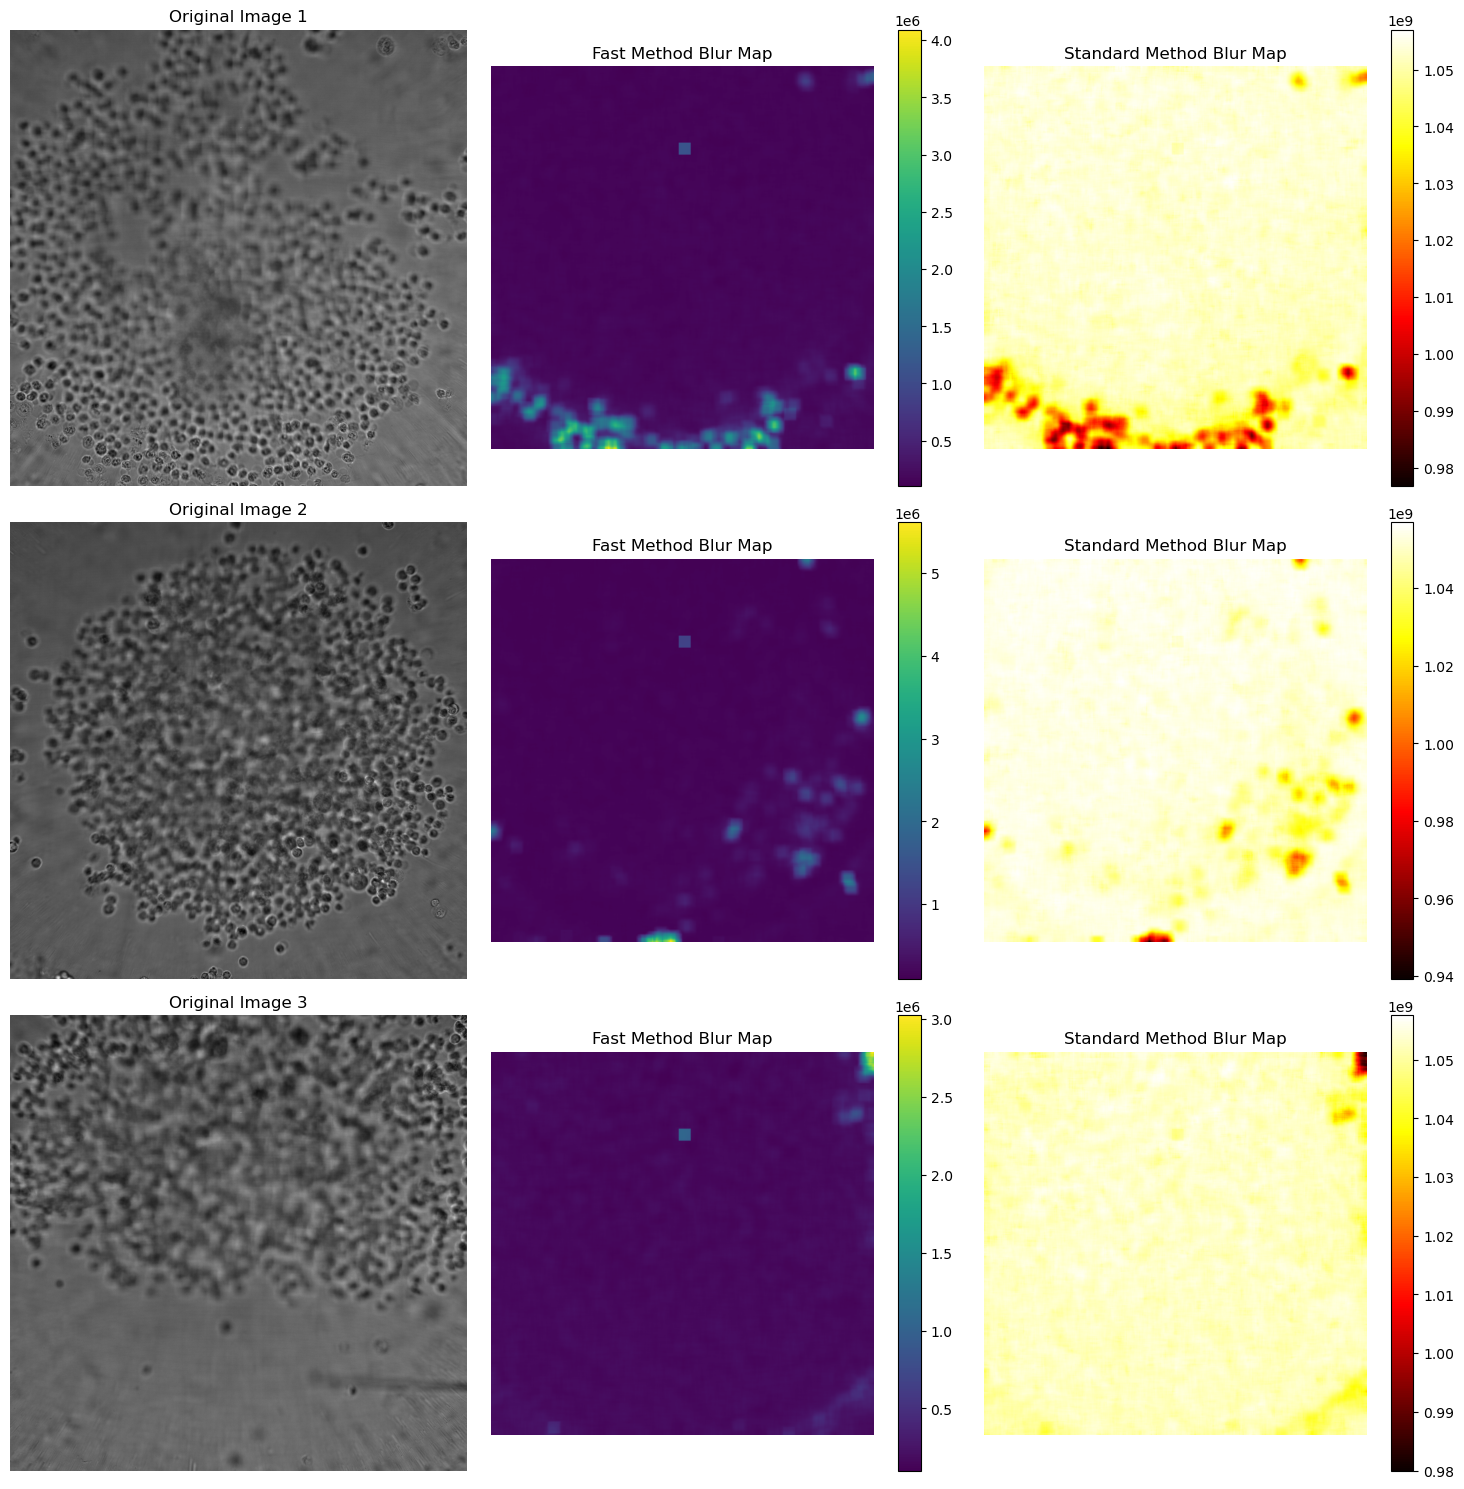

In [24]:

# import matplotlib
# matplotlib.use("module://matplotlib_inline.backend_inline")
# import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(n_images, 3, figsize=(15, 5 * n_images))

for i, img_name in enumerate(results_img):
    print(i, img_name)
    image = results_img[img_name]['image']
    blur_map_fast = results_img[img_name]['blur_map_fast']
    blur_map_standard = results_img[img_name]['blur_map_standard']

    # Plot original image
    axes[i, 0].imshow(image, cmap='gray')
    axes[i, 0].set_title(f'Original Image {i+1}')
    axes[i, 0].axis('off')

    # Plot fast method blur map
    im1 = axes[i, 1].imshow(blur_map_fast)
    axes[i, 1].set_title('Fast Method Blur Map')
    axes[i, 1].axis('off')
    plt.colorbar(im1, ax=axes[i, 1])

    # Plot standard method blur map
    im2 = axes[i, 2].imshow(blur_map_standard, cmap='hot')
    axes[i, 2].set_title('Standard Method Blur Map')
    axes[i, 2].axis('off')
    plt.colorbar(im2, ax=axes[i, 2])

plt.tight_layout()
plt.show()
